#  EXPLORATORY DATA ANALYSIS (EDA)

In [34]:
import pandas as pd

In [35]:
df = pd.read_csv('movies_data_cleaned.csv')

In [36]:
df.head()

,title,year,genres,director,original_language,budget,revenue,rating,age_rating,awarded,primary_genre,runtime_minutes,profit,roi,genre_count
0,Avatar Aang: The Last Airbender,2026,"Animation , Action , Adventure , Fantasy",Tim Hedrick,English,NaN,NaN,92,Family Friendly,0,Animation,99,NaN,NaN,4
1,Accidental Partners,2026,"Comedy, Romance",Ihtzi Hurtado,Spanish; Castilian,NaN,NaN,89,Teen,0,Comedy,110,NaN,NaN,2
2,Swapped,2026,"Adventure , Animation , Family , Fantasy",Nathan Greno,English,NaN,7.0,89,Family Friendly,0,Adventure,102,NaN,NaN,4
3,Facing El Chapo,2026,"Crime , Action , Thriller",Chava Cartas,Spanish; Castilian,NaN,NaN,88,Adult,0,Crime,91,NaN,NaN,3
4,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025,"Animation , Action , Fantasy",Haruo Sotozaki,Japanese,20000000.0,733030221.0,88,Adult,1,Animation,156,713030221.0,3565.151105,3


In [37]:
df.shape

(2000, 15)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              2000 non-null   object 
 1   year               2000 non-null   int64  
 2   genres             2000 non-null   object 
 3   director           2000 non-null   object 
 4   original_language  2000 non-null   object 
 5   budget             1276 non-null   float64
 6   revenue            1450 non-null   float64
 7   rating             2000 non-null   int64  
 8   age_rating         2000 non-null   object 
 9   awarded            2000 non-null   int64  
 10  primary_genre      2000 non-null   object 
 11  runtime_minutes    2000 non-null   int64  
 12  profit             1178 non-null   float64
 13  roi                1178 non-null   float64
 14  genre_count        2000 non-null   int64  
dtypes: float64(4), int64(5), object(6)
memory usage: 234.5+ KB


In [39]:
df['budget_in_mil'] = df['budget'].apply(lambda x: x/1000000)
df['revenue_in_mil'] = df['revenue'].apply(lambda x: x/1000000)
df['profit_in_mil'] = df['profit'].apply(lambda x: x/1000000)

In [74]:
df['IsHit'] = df['profit'].apply(lambda x: 1 if x > 0 else 0)

In [40]:
df[['rating', 'runtime_minutes', 'budget_in_mil', 'revenue_in_mil', 'profit_in_mil', 'roi']].describe()

,rating,runtime_minutes,budget_in_mil,revenue_in_mil,profit_in_mil,roi
count,2000.000000,2000.000000,1276.000000,1450.000000,1178.000000,1178.000000
mean,77.231000,113.613000,32.636026,136.657668,130.194417,841.568943
std,2.806168,31.720235,53.171773,287.618653,272.259007,3085.166872
min,74.000000,4.000000,0.000117,0.000006,-185.600000,-99.999839
25%,75.000000,97.000000,3.000000,5.666000,3.721178,71.642673
50%,77.000000,112.000000,12.000000,30.394281,29.456635,285.692388
75%,79.000000,129.000000,34.000000,119.647517,118.696059,668.678539
max,92.000000,367.000000,460.000000,2923.706026,2686.706026,67332.895333


## Movie Trends Over Time

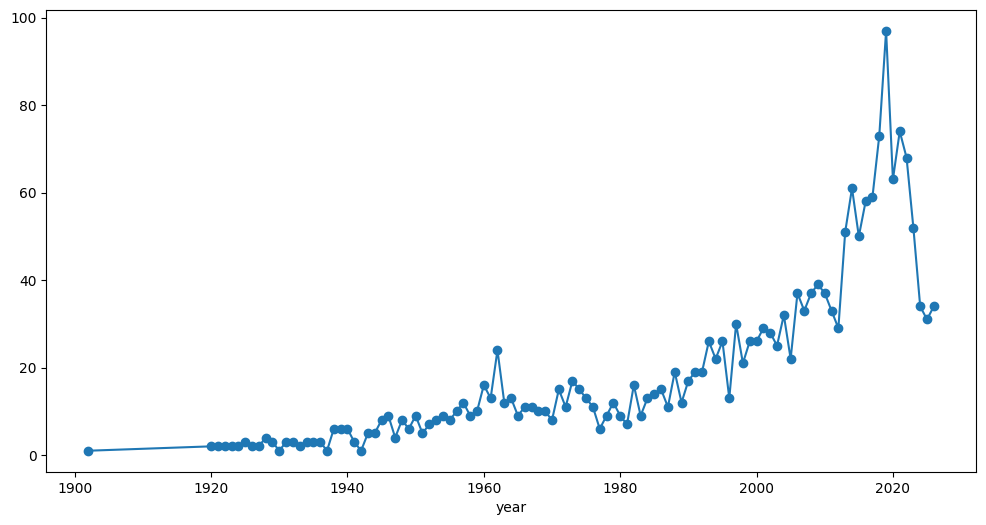

In [41]:
# Count of Movies over the Years
movies_by_year = df['year'].value_counts().sort_index()

movies_by_year.plot(
    kind='line',
    figsize=(12,6),
    marker='o'
);
# Most frequency is around 2020 for the top rated movies

In [42]:
# Avg rating highest for the year 2026 and 1931 then 1957
yearly_rating = df.groupby('year')['rating'].mean()
yearly_rating.sort_values(ascending=False)

,rating
year,
2026,80.823529
1931,79.666667
1957,79.500000
1927,79.500000
1954,79.111111
...,...
1933,75.500000
1932,75.333333
1929,75.333333


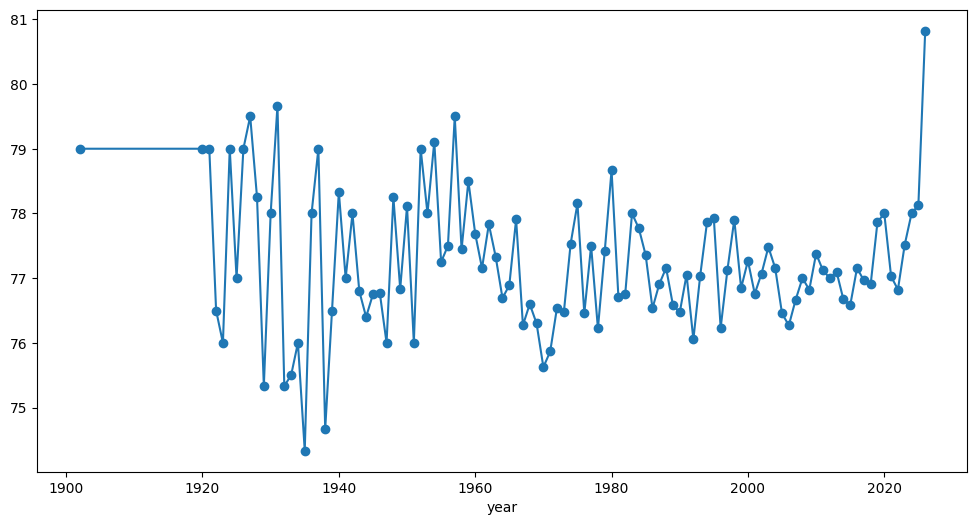

In [43]:
yearly_rating.plot(
    kind='line',
    figsize=(12,6),
    marker='o'
);

In [44]:
# Box office revenue is the highest for year 2026, 2025 and then 2012
yearly_revenue = df.groupby('year')['revenue_in_mil'].mean()
yearly_revenue.sort_values(ascending=False)

,revenue_in_mil
year,
2026,421.075246
2025,402.937817
2012,264.541854
2009,222.712782
2022,208.180667
...,...
1920,0.008811
1902,NaN
1924,NaN


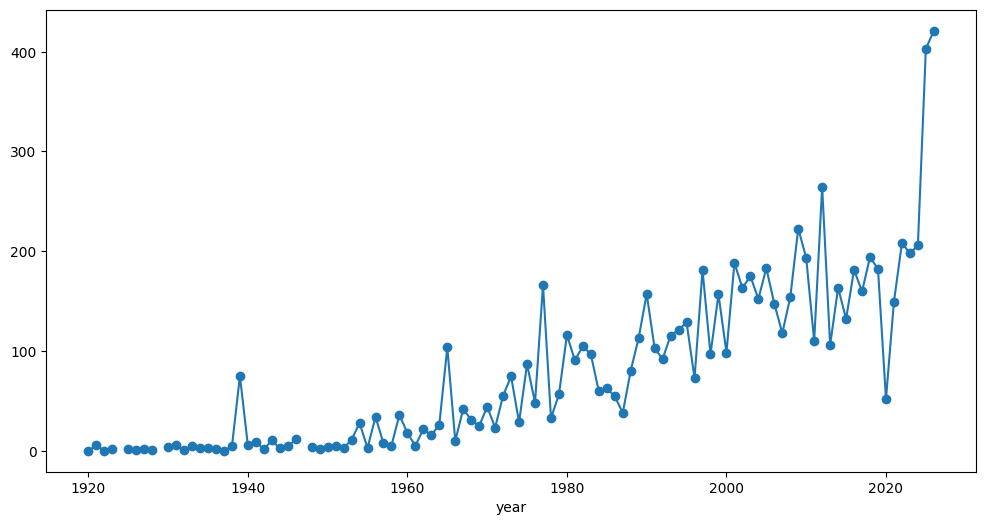

In [45]:
yearly_revenue.plot(
    kind='line',
    figsize=(12,6),
    marker='o'
);

## Genre Analysis

In [46]:
# Drama is the most frequent primary genre of the movies
genre_counts = df['primary_genre'].value_counts()
genre_counts

,count
primary_genre,
Drama,682
Comedy,233
Animation,233
Action,174
Crime,102
Adventure,100
Documentary,84
Romance,68
Thriller,51


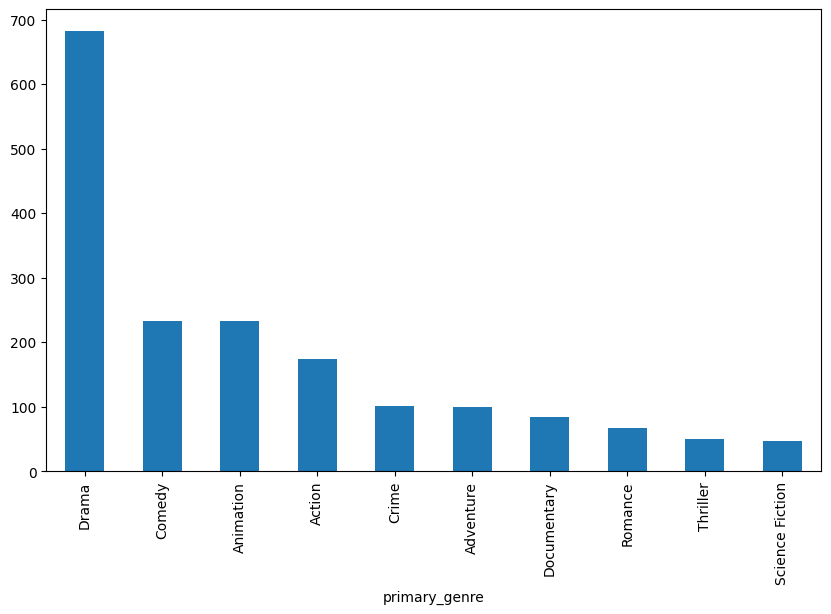

In [47]:
# Top 10 Genres - Movie Count
genre_counts.head(10).plot(
    kind='bar',
    figsize=(10,6)
);

In [48]:
# Avg rating is highest for Tv movie, Documentary and Music genre
genre_rating = (
    df.groupby('primary_genre')['rating']
      .mean()
      .sort_values(ascending=False)
)
genre_rating

,rating
primary_genre,
TV Movie,79.000000
Documentary,78.142857
Music,78.000000
Animation,77.896996
Adventure,77.530000
Romance,77.294118
Drama,77.275660
Fantasy,77.200000
Family,77.128205


In [49]:
# Avg profit is highest for Adventure and Science Fiction genre movies
genre_profit = (
    df.groupby('primary_genre')['profit_in_mil']
      .mean()
      .sort_values(ascending=False)
)
genre_profit

,profit_in_mil
primary_genre,
Adventure,370.322966
Science Fiction,330.792844
Family,253.802087
Animation,238.131172
Action,222.879122
Music,191.259658
Fantasy,171.016613
War,124.462620
Horror,110.134789


## Rating Analysis

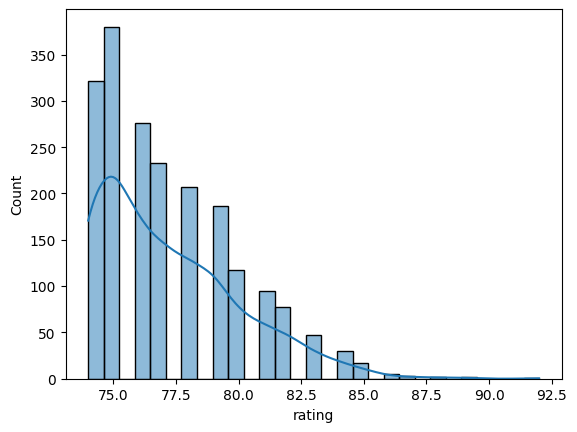

In [53]:
# Right Skewed Rating Distribution
# Most data lies under 80% Rating
import seaborn as sns
sns.histplot(data=df,x='rating',kde=True);

## Revenue Analysis

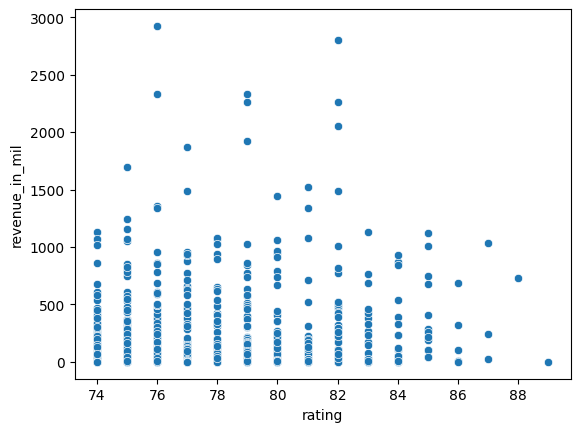

In [58]:
# Some movies rating <= 82 have earned exceptionally high revenue touching 3000 millions.
# Rating > 82 have earned <= 1000 millions
sns.scatterplot(data=df,x='rating',y='revenue_in_mil');

In [60]:
# slight / weak positive correlation
df[['revenue','rating']].corr()

,revenue,rating
revenue,1.000000,0.143659
rating,0.143659,1.000000


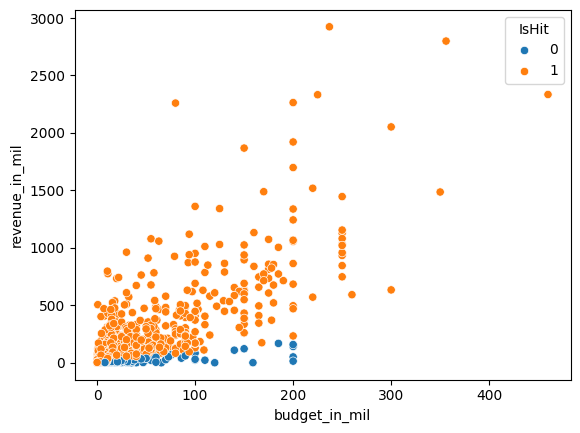

In [93]:
sns.scatterplot(data=df,x='budget_in_mil',y='revenue_in_mil', hue='IsHit');

In [63]:
# Strong correlation can be seen between budget and revenue -> 0.77
df[['revenue','budget']].corr()

,revenue,budget
revenue,1.00000,0.77029
budget,0.77029,1.00000


In [67]:
df['profit_in_mil'].mean()

np.float64(130.19441671816637)

In [69]:
# Positively Skewed
df['profit_in_mil'].skew()

np.float64(4.1778176137385)

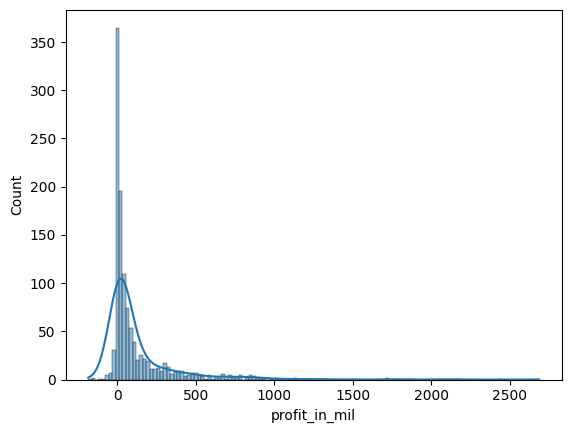

In [70]:
sns.histplot(data=df,x='profit_in_mil',kde=True);

## Correlation Heatmap

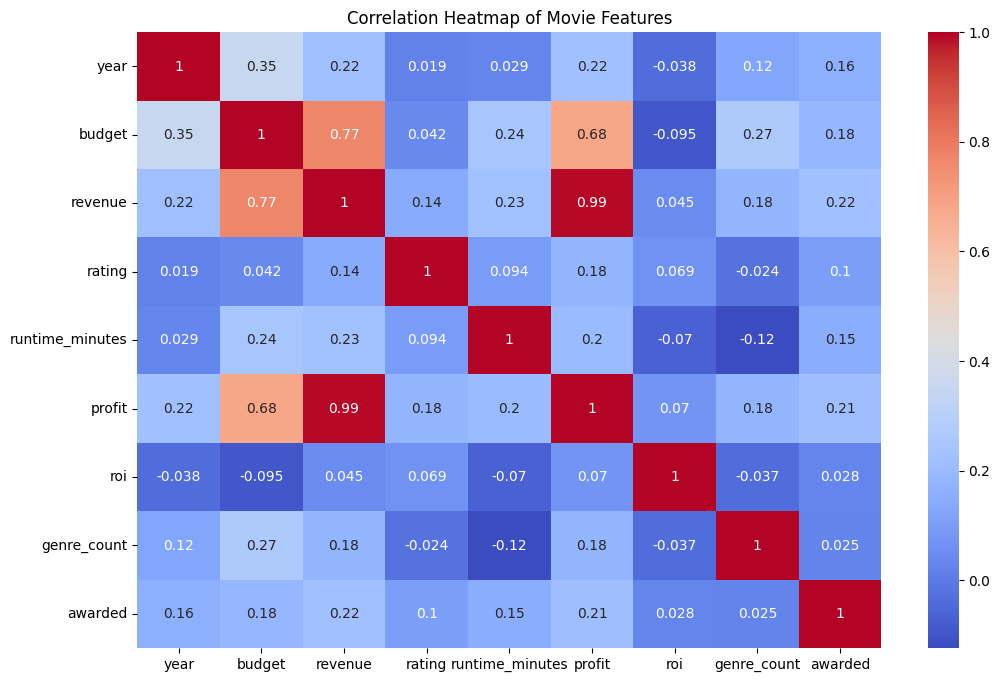

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'year',
    'budget',
    'revenue',
    'rating',
    'runtime_minutes',
    'profit',
    'roi',
    'genre_count',
    'awarded'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
)

plt.title('Correlation Heatmap of Movie Features')
plt.show()

In [72]:
# Profit has strong correlation with budget and revenue.
# Profit has slight positive (around 0.2) correlation with
# Year, Rating, Runtime, Genre Count and Awards

In [73]:
# Rating has almost negligible correlation with any col,
# slight positive correlation with awards and revenue

## Outlier Analysis

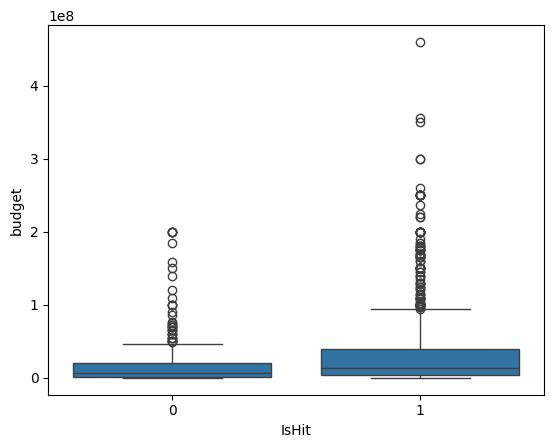

In [89]:
sns.boxplot(data=df,x='IsHit',y='budget');

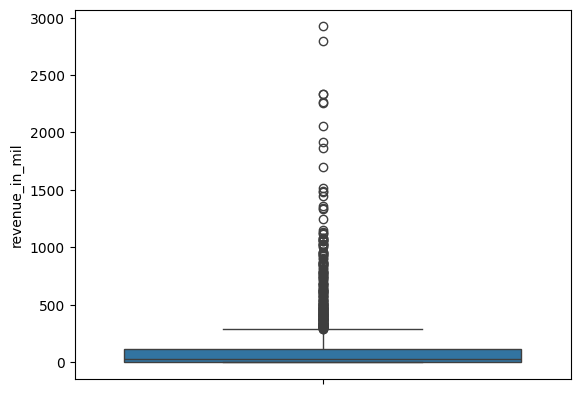

In [88]:
sns.boxplot(data=df,y='revenue_in_mil');

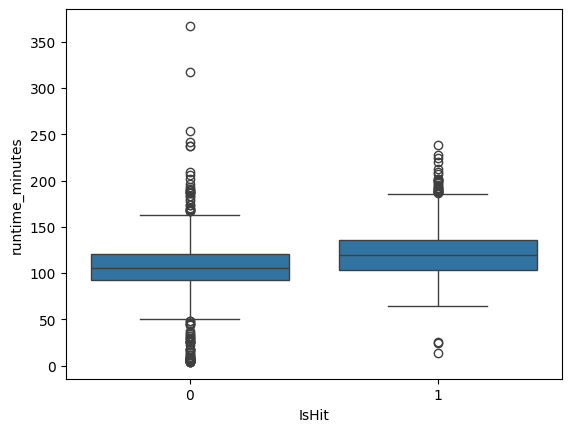

In [87]:
# The Avg runtime of Hit movies is higher but the spread is less
sns.boxplot(data=df,x='IsHit',y='runtime_minutes');

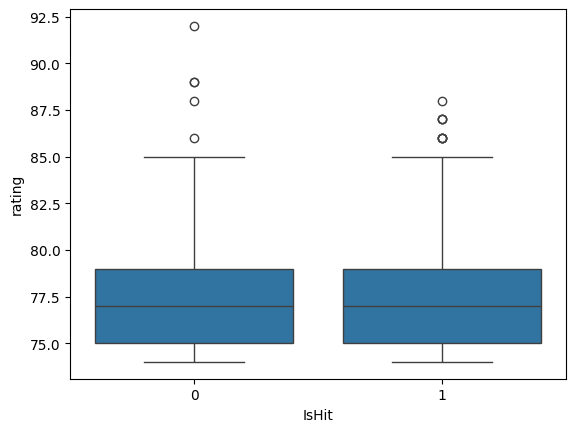

In [91]:
# Sometimes even the flop have higher ratings
sns.boxplot(data=df,x='IsHit',y='rating');

In [92]:
df.to_csv('movies_data_eda.csv',index=False)

## Top Insights

In [95]:
# 1. Profitability is highly skewed: Most movies generate moderate profits,
# while a small number of blockbusters produce exceptionally high returns.

# 2. Ratings don't vary as much as revenue: Movie ratings are relatively
# concentrated around the mid-to-high 70s, whereas revenue varies
# dramatically, suggesting that strong ratings alone may not guarantee
# commercial success.

# 3. Financial data is incomplete: Only 1,178 of 2,000 movies have
# both budget and revenue available, limiting the number of movies that
# can be reliably used for profitability and ROI analysis.